# Shifting Detector

In [1]:
import argparse
import time
import os
import numpy as np
import torch
import sys

from utils import *

sys.path.insert(0, 'bao_server')
import bao_server.model as model
import copy
import random

sys.path.append('ShiftHandler')
from replay_buffer import summarizer

## 1. Load DataSet

### 1.1 load all datasets - queries, plans, latecies

In [2]:
import json
import pandas as pd
import ast

df = pd.read_csv("dataset/tpc-h-shifting/execution_results.csv")
df["latency_list"] = df["latency_list"].apply(ast.literal_eval)

def load_plans(plan_path):
    with open(plan_path, "r") as f:
        return json.load(f)

df["plans"] = df["plan_path"].apply(load_plans)

In [3]:
def wrap_plan(plan):
    if "Plan" in plan:
        return plan
    return {"Plan": plan}

df["plans"] = df["plans"].apply(
    lambda plans: [wrap_plan(p) for p in plans]
)

In [4]:
# # Varify the dataframe
# row = df.iloc[0]
# print(row["query_id"])
# print(len(row["latency_list"]))
# print(len(row["plans"]))


In [5]:
p0_df = df[df["phase"] == "phase_0"]
p1_df = df[df["phase"] == "phase_1"]
p2_df = df[df["phase"] == "phase_2"]

X = []
y = []
for _, row in p0_df.iterrows():
    plans = row["plans"]
    latencies = row["latency_list"]
    for plan, latency in zip(plans, latencies):
        X.append(plan)
        y.append(latency)

In [6]:
# sample = X_fixed[0]
# print(sample.keys())
# print(sample["Plan"].keys())

In [7]:
# print(len(X))
# print(len(y))
# print(X_fixed[0])


## 2. Training BAO Model

In [8]:
# TODO:// have_cache_data=False, since Buffer Feature missed. Fix it later
reg = model.BaoRegression(have_cache_data=False, verbose=False)
try:
    reg.fit_feature_extractor(X, y)
except Exception as e:
    print("ERROR:", e)

In [9]:
reg.fit_model(X, y, seed=42, ada_size=False)

([tensor(382),
  tensor(33),
  tensor(104),
  tensor(457),
  tensor(70),
  tensor(10),
  tensor(446),
  tensor(165),
  tensor(110),
  tensor(37),
  tensor(308),
  tensor(188),
  tensor(106),
  tensor(310),
  tensor(225),
  tensor(322),
  tensor(99),
  tensor(121),
  tensor(3),
  tensor(296),
  tensor(269),
  tensor(439),
  tensor(437),
  tensor(208),
  tensor(16),
  tensor(443),
  tensor(359),
  tensor(284),
  tensor(395),
  tensor(79),
  tensor(242),
  tensor(262),
  tensor(227),
  tensor(418),
  tensor(375),
  tensor(239),
  tensor(351),
  tensor(222),
  tensor(268),
  tensor(47),
  tensor(66),
  tensor(507),
  tensor(243),
  tensor(271),
  tensor(519),
  tensor(468),
  tensor(459),
  tensor(42),
  tensor(77),
  tensor(9),
  tensor(130),
  tensor(291),
  tensor(206),
  tensor(500),
  tensor(92),
  tensor(89),
  tensor(199),
  tensor(30),
  tensor(348),
  tensor(139),
  tensor(366),
  tensor(163),
  tensor(474),
  tensor(119),
  tensor(142),
  tensor(256),
  tensor(147),
  tensor(230)

## 3. Predict Other Phases Dataset

In [10]:
def prediction(data):
    results = []
    for _, row in data.iterrows():
        plans = row["plans"]
        latencies = row["latency_list"]
        preds = reg.predict(plans)
        chosen_idx = np.argmin(preds)
        best_idx = np.argmin(latencies)
        result = {
            "query_id": row["query_id"],
            "bao_latency":
                latencies[chosen_idx],
            "best_latency":
                latencies[best_idx],
            "default_latency":
                latencies[0],
            "regret":
                latencies[chosen_idx]
                / latencies[best_idx],
        }

        results.append(result)
    return pd.DataFrame(results)

因此我建议最终论文主图用：
Normalized Latency (Default/Bao/Optimal) ← 主图
Regret vs Phase ← 核心结果
MMD Score + Retrain Point ← 方法验证
Top-1 Accuracy ← 辅助结果
这四张图基本就能完整支撑整个 Continual LQO 论文的实验部分。

In [11]:
def plot_res(phase_name, pre_results):
    import matplotlib.pyplot as plt

    default_latency_list = pre_results["default_latency"]
    bao_latency_list = pre_results["bao_latency"]
    optimal_latency_list = pre_results["best_latency"]

    # 累积Latency
    default_cum = np.cumsum(default_latency_list)
    bao_cum = np.cumsum(bao_latency_list)
    optimal_cum = np.cumsum(optimal_latency_list)

    # Query编号
    x = np.arange(1, len(default_cum) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(x, default_cum,
             linewidth=2,
             label="PostgreSQL Default")
    plt.plot(x, bao_cum,
             linewidth=2,
             label="Bao")
    plt.plot(x, optimal_cum,
             linewidth=2,
             label="Optimal")
    plt.xlabel("Number of Queries", fontsize=12)
    plt.ylabel("Cumulative Latency (ms)", fontsize=12)
    plt.title(f"Cumulative Query Latency for {phase_name}", fontsize=14)

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

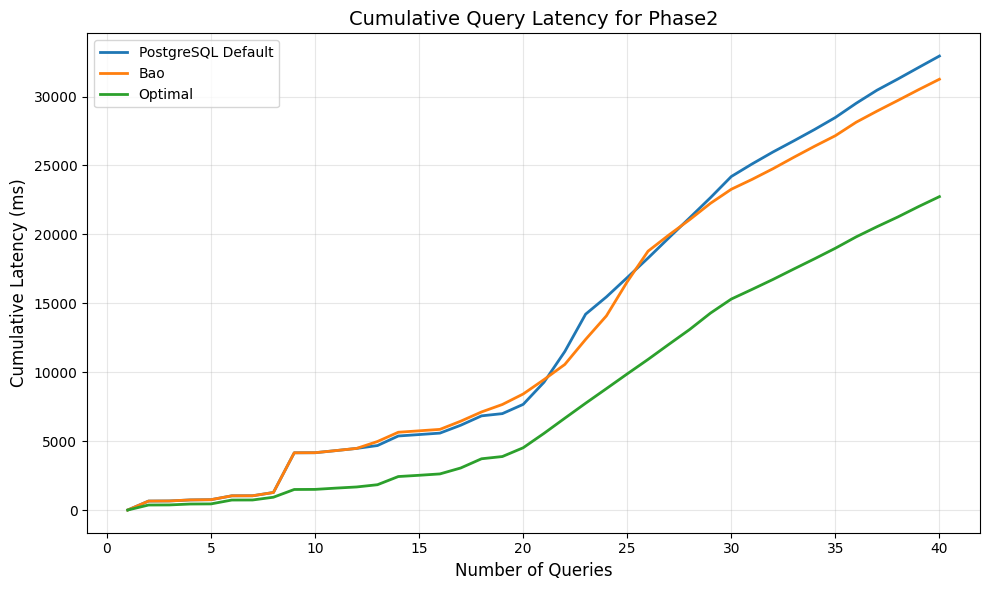

In [12]:
res = prediction(p2_df)
plot_res("Phase2",res)

## 4. Queries(Plans) Featurization

In [13]:
p0_plans = []
for plans in p0_df["plans"]:
    p0_plans.extend(plans)
tree_p0 = reg._BaoRegression__tree_transform.transform(p0_plans)
emb_p0 = reg._BaoRegression__net.get_fixed_features(tree_p0)
# print(len(p0_plans))

p2_sample = p2_df.iloc[-1]["plans"]
# print(x2_sample)
tree_s2 = reg._BaoRegression__tree_transform.transform(p2_sample)
emb_s2 = reg._BaoRegression__net.get_fixed_features(tree_s2)

## 5. MMD

In [14]:
from torch.autograd import Variable

def guassian_kernel(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    n_samples = int(source.size()[0]) + int(target.size()[0])
    total = torch.cat([source, target], dim=0)
    total0 = total.unsqueeze(0).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
    total1 = total.unsqueeze(1).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
    L2_distance = ((total0 - total1) ** 2).sum(2)
    if fix_sigma:
        bandwidth = fix_sigma
    else:
        bandwidth = torch.sum(L2_distance.data) / (n_samples ** 2 - n_samples)
    bandwidth /= kernel_mul ** (kernel_num // 2)
    bandwidth_list = [bandwidth * (kernel_mul ** i) for i in range(kernel_num)]
    kernel_val = [torch.exp(-L2_distance / bandwidth_temp) for bandwidth_temp in bandwidth_list]
    return sum(kernel_val)  #/len(kernel_val)


def mmd(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    n = int(source.size()[0])
    m = int(target.size()[0])

    kernels = guassian_kernel(source, target,
                              kernel_mul=kernel_mul, kernel_num=kernel_num, fix_sigma=fix_sigma)
    XX = kernels[:n, :n]
    YY = kernels[n:, n:]
    XY = kernels[:n, n:]
    YX = kernels[n:, :n]

    XX = torch.div(XX, n * n).sum(dim=1).view(1, -1)  # K_ss矩阵，Source<->Source
    XY = torch.div(XY, -n * m).sum(dim=1).view(1, -1)  # K_st矩阵，Source<->Target

    YX = torch.div(YX, -m * n).sum(dim=1).view(1, -1)  # K_ts矩阵,Target<->Source
    YY = torch.div(YY, m * m).sum(dim=1).view(1, -1)  # K_tt矩阵,Target<->Target

    loss = (XX + XY).sum() + (YX + YY).sum()
    return loss

In [15]:
# MMD compute sample for p0 all plans and p2 a sample
print("MMD Loss (d1,d2):", mmd(emb_p0, emb_s2))

MMD Loss (d1,d2): tensor(0.6054, device='cuda:0', grad_fn=<AddBackward0>)


## 6. Relationship of MMD score & Regret

In [16]:
emb_p0

tensor([[0.2827, 0.2930, 0.2858,  ..., 0.2827, 0.2827, 0.2892],
        [0.3301, 0.3422, 0.3337,  ..., 0.3301, 0.3301, 0.5329],
        [0.3274, 0.3394, 0.3311,  ..., 0.3274, 0.3274, 0.5403],
        ...,
        [0.4077, 0.4077, 0.4077,  ..., 0.4077, 0.4077, 0.8322],
        [0.4060, 0.4060, 0.4060,  ..., 0.4060, 0.4060, 0.5935],
        [0.4319, 0.4319, 0.4319,  ..., 0.4319, 0.4319, 0.9191]],
       device='cuda:0', grad_fn=<MaxBackward0>)

In [17]:
mmd_score_p1 = []

p1_plans = p1_df["plans"]
for p in p1_plans:
    trees = reg._BaoRegression__tree_transform.transform(p)
    embedding = reg._BaoRegression__net.get_fixed_features(trees)
    mmd_score_p1.append(mmd(embedding, emb_p0))


In [18]:
res_1 = prediction(p1_df)
regrets_1 = res["regret"]
res_2 = prediction(p2_df)
regrets_2 = res["regret"]

In [19]:
print(type(regrets_1))
print(type(mmd_score_p1))

<class 'pandas.core.series.Series'>
<class 'list'>


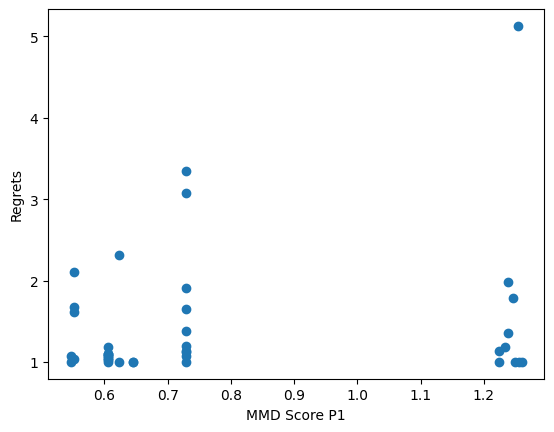

In [20]:
import matplotlib.pyplot as plt

x_np = [t.item() for t in mmd_score_p1]
y_np = list(regrets_1)

# 3. Create the scatter plot
plt.scatter(x_np, y_np)
plt.xlabel("MMD Score P1")
plt.ylabel("Regrets")
plt.show()

## 7. K-S test vs regret

In [21]:
from scipy.stats import ks_2samp
import numpy as np

def ks_values(phase0, phase1):
    p_values = []
    for d in range(64):
        stat, p = ks_2samp(phase0[:, d], phase1[:, d])
        p_values.append(p)

    return (min(p_values))

In [28]:
print(type(emb_p0))
embedding_p0 = emb_p0.cpu().detach().numpy()
print(type(embedding_p0))

<class 'torch.Tensor'>
<class 'numpy.ndarray'>


In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
ks_stat_p1 = []
ks_p_values_p1 = []
p1_plans = p2_df["plans"]
# PCA到1维
phase0_1d = pca.fit_transform(embedding_p0)


for p in p1_plans:
    trees = reg._BaoRegression__tree_transform.transform(p)
    embedding = reg._BaoRegression__net.get_fixed_features(trees).cpu().detach().numpy()
    phase1_1d = pca.transform(embedding)
    ks_stat_i, p_i = ks_2samp(phase0_1d[:,0], phase1_1d[:,0])
    ks_stat_p1.append(ks_stat_i)
    ks_p_values_p1.append(p_i)

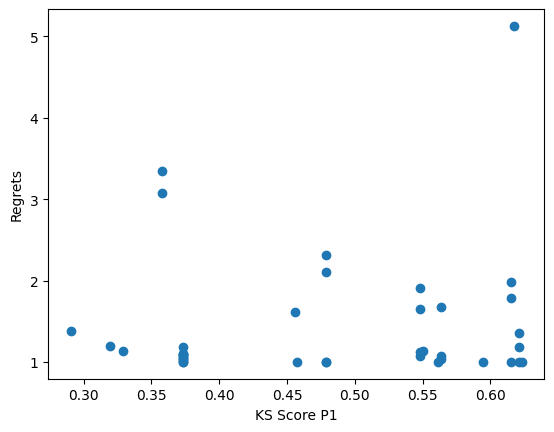

In [30]:
x_np_ks = ks_stat_p1
y_np_ks = list(regrets_2)

# 3. Create the scatter plot
plt.scatter(x_np_ks, y_np_ks)
plt.xlabel("KS Score P1")
plt.ylabel("Regrets")
plt.show()

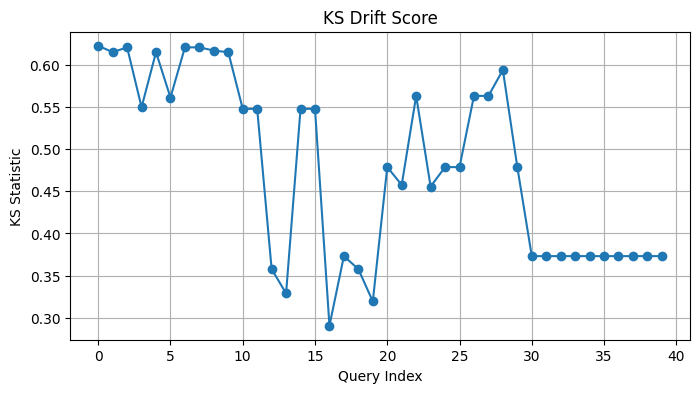

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    range(len(ks_stat_p1)),
    ks_stat_p1,
    marker='o'
)

plt.xlabel("Query Index")
plt.ylabel("KS Statistic")
plt.title("KS Drift Score")

plt.grid(True)

plt.savefig(
    "ks_drift_score.pdf",
    bbox_inches="tight"
)

plt.show()


Text(0.5, 0, 'Query Index')

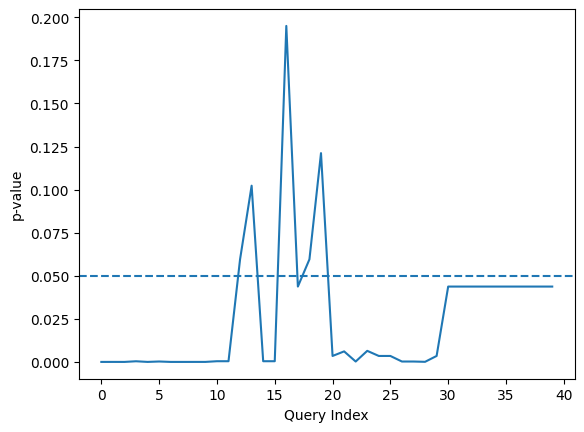

In [32]:
plt.plot(ks_p_values_p1)

plt.axhline(
    y=0.05,
    linestyle="--"
)

plt.ylabel("p-value")
plt.xlabel("Query Index")

## 8. KL-Divergence Or JSD vs Regrets

## 9. Wassertein Distance vs Regrets

In [33]:
from scipy.stats import wasserstein_distance

# phase0_1d existed
wd_score_p1 = []

for p in p1_plans:
    trees = reg._BaoRegression__tree_transform.transform(p)
    embedding = reg._BaoRegression__net.get_fixed_features(trees).cpu().detach().numpy()
    phase1_1d = pca.transform(embedding)
    wd = wasserstein_distance(phase0_1d[:,0],phase1_1d[:,0])
    wd_score_p1.append(wd)


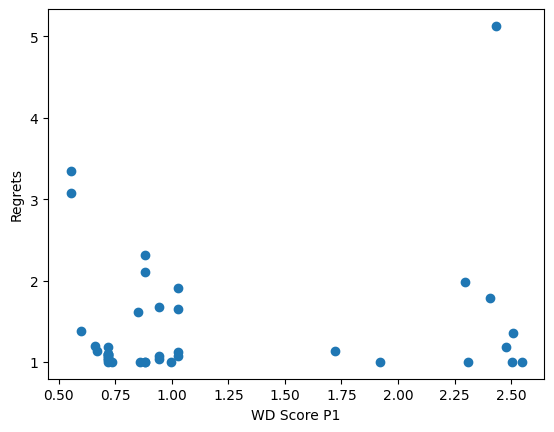

In [34]:
x_np = [t.item() for t in wd_score_p1]
y_np = list(regrets_1)

# 3. Create the scatter plot
plt.scatter(x_np, y_np)
plt.xlabel("WD Score P1")
plt.ylabel("Regrets")
plt.show()